# Random Search Hyperparameter Optimization

This notebook applies Random Search to optimize the hyperparameters of a Genetic Algorithm designed to recreate *Girl with a Pearl Earring* using semi-transparent triangles.

Unlike manual tuning, Random Search automatically samples random combinations of hyperparameters from predefined search spaces. This allows the exploration of multiple Genetic Algorithm configurations without relying on human intuition.

The objective of this experiment is to evaluate the effectiveness of Random Search as a baseline hyperparameter optimization strategy and compare its behavior with more advanced optimization methods such as Optuna.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ga_core import *

## Target Image

The following image is used as the optimization target throughout the Random Search experiments.

In [2]:
target = load_target_image("girl_pearl_earing.png")

In [ ]:
plt.figure(figsize=(4, 5))

plt.imshow(target)
plt.title("Target Image")
plt.axis("off")

plt.show()

## Random Search Configuration

The following search space defines the possible hyperparameter combinations explored during Random Search.

Each trial randomly samples a different Genetic Algorithm configuration, including:
- population size;
- mutation rate;
- elitism size;
- tournament size;
- selection strategy;
- crossover strategy;
- crossover probability;
- mutation decay usage.

In [ ]:
RANDOM_SEARCH_TRIALS = 20
RANDOM_SEARCH_GENERATIONS = 500

POP_SIZE_OPTIONS = [20, 30, 40]
MUTATION_RATE_RANGE = (0.005, 0.12)
ELITE_SIZE_RANGE = (1, 6)
TOURNAMENT_SIZE_RANGE = (2, 8)

SELECTION_OPTIONS = ["tournament", "roulette"]
CROSSOVER_OPTIONS = ["one_point", "uniform"]
CROSSOVER_RATE_RANGE = (0.60, 1.00)
MUTATION_DECAY_OPTIONS = [False, True]

## Random Configuration Sampling

The following function randomly samples one complete Genetic Algorithm configuration from the predefined search space.

Each sampled configuration defines not only numerical hyperparameters, such as mutation rate and population size, but also structural choices such as the selection method, crossover strategy, and whether mutation decay is used.

This makes Random Search a useful baseline for exploring different GA designs without manually testing each possible combination.

In [ ]:
def sample_random_configuration():
    """
    Randomly samples one complete GA configuration from the predefined search space.
    """

    pop_size = random.choice(POP_SIZE_OPTIONS)

    elite_size = random.randint(
        ELITE_SIZE_RANGE[0],
        min(ELITE_SIZE_RANGE[1], pop_size // 5)
    )

    selection_type = random.choice(SELECTION_OPTIONS)

    if selection_type == "tournament":
        tournament_size = random.randint(
            TOURNAMENT_SIZE_RANGE[0],
            min(TOURNAMENT_SIZE_RANGE[1], pop_size)
        )
    else:
        tournament_size = 2

    config = {
        "pop_size": pop_size,
        "generations": RANDOM_SEARCH_GENERATIONS,
        "mutation_rate": random.uniform(
            MUTATION_RATE_RANGE[0],
            MUTATION_RATE_RANGE[1]
        ),
        "elite_size": elite_size,
        "selection_type": selection_type,
        "tournament_size": tournament_size,
        "crossover_type": random.choice(CROSSOVER_OPTIONS),
        "crossover_rate": random.uniform(
            CROSSOVER_RATE_RANGE[0],
            CROSSOVER_RATE_RANGE[1]
        ),
        "use_mutation_decay": random.choice(MUTATION_DECAY_OPTIONS),
        "min_mutation_rate": 0.01
    }

    return config

## Random Search Execution

The following function executes the Random Search optimization process.

For each trial, a completely different Genetic Algorithm configuration is randomly sampled and evaluated. The algorithm is then executed using the selected configuration, and the final RMSE is stored together with the corresponding hyperparameters.

This process allows the exploration of multiple combinations of:
- mutation behavior;
- population structure;
- selection strategy;
- crossover strategy;
- mutation decay usage.

At the end of the search, all configurations can be compared to identify which combinations produce the best image approximation quality.

In [5]:
def run_random_search(target_img, n_trials=RANDOM_SEARCH_TRIALS):
    """
    Runs Random Search over several GA configurations.
    """

    results = []

    for trial in range(n_trials):
        print("=" * 70)
        print(f"Random Search Trial {trial + 1}/{n_trials}")

        config = sample_random_configuration()

        print(config)

        result = evolve_configurable(
            target_img=target_img,
            pop_size=config["pop_size"],
            generations=config["generations"],
            mutation_rate=config["mutation_rate"],
            elite_size=config["elite_size"],
            selection_type=config["selection_type"],
            tournament_size=config["tournament_size"],
            crossover_type=config["crossover_type"],
            crossover_rate=config["crossover_rate"],
            use_mutation_decay=config["use_mutation_decay"],
            min_mutation_rate=config["min_mutation_rate"],
            snapshot_generations=[config["generations"] - 1],
            print_every=None
        )

        best_individual = result["best_individual"]
        background_color = result["background_color"]

        final_image = render_individual(
            best_individual,
            background_color
        )

        final_rmse = calculate_fitness(
            final_image,
            target_img
        )

        trial_result = {
            "trial": trial + 1,
            "final_rmse": final_rmse,
            "final_image": final_image,
            "history": result["history"],
            **config
        }

        results.append(trial_result)

        print(f"Final RMSE: {final_rmse:.4f}")

    return results

## Running Random Search

The Random Search procedure is executed for a predefined number of trials.

During each trial, a new Genetic Algorithm configuration is randomly generated and evaluated. The final RMSE obtained by each configuration is stored for later comparison and analysis.

The goal is to identify which hyperparameter combinations lead to better convergence and image reconstruction quality.

In [6]:
random_search_results = run_random_search(
    target_img=target,
    n_trials=RANDOM_SEARCH_TRIALS
)

Random Search Trial 1/20
{'pop_size': 40, 'generations': 500, 'mutation_rate': 0.03662837161244871, 'elite_size': 1, 'selection_type': 'tournament', 'tournament_size': 7, 'crossover_type': 'one_point', 'crossover_rate': 0.6558151714100575, 'use_mutation_decay': False, 'min_mutation_rate': 0.01}
Final RMSE: 29.4490
Random Search Trial 2/20
{'pop_size': 40, 'generations': 500, 'mutation_rate': 0.014198528057431499, 'elite_size': 6, 'selection_type': 'roulette', 'tournament_size': 2, 'crossover_type': 'one_point', 'crossover_rate': 0.8488514324284929, 'use_mutation_decay': True, 'min_mutation_rate': 0.01}
Final RMSE: 36.9887
Random Search Trial 3/20
{'pop_size': 20, 'generations': 500, 'mutation_rate': 0.04710406171059205, 'elite_size': 2, 'selection_type': 'tournament', 'tournament_size': 6, 'crossover_type': 'one_point', 'crossover_rate': 0.8540555145298792, 'use_mutation_decay': False, 'min_mutation_rate': 0.01}
Final RMSE: 31.8651
Random Search Trial 4/20
{'pop_size': 20, 'generations

## Random Search Results

The table below summarizes the performance obtained by the different Genetic Algorithm configurations sampled during Random Search.

Each row represents one independent trial with a unique combination of:
- population size;
- mutation rate;
- elitism;
- selection strategy;
- crossover strategy;
- mutation decay usage.

The configurations are sorted by final RMSE, allowing direct comparison between the best and worst performing combinations.

In [7]:
random_search_df = pd.DataFrame([
    {
        "trial": result["trial"],
        "final_rmse": result["final_rmse"],
        "pop_size": result["pop_size"],
        "mutation_rate": result["mutation_rate"],
        "elite_size": result["elite_size"],
        "selection_type": result["selection_type"],
        "tournament_size": result["tournament_size"],
        "crossover_type": result["crossover_type"],
        "crossover_rate": result["crossover_rate"],
        "use_mutation_decay": result["use_mutation_decay"]
    }
    for result in random_search_results
])

random_search_df = random_search_df.sort_values(
    by="final_rmse",
    ascending=True
)

random_search_df

,trial,final_rmse,pop_size,mutation_rate,elite_size,selection_type,tournament_size,crossover_type,crossover_rate,use_mutation_decay
12,13,26.791636,40,0.066219,3,tournament,8,one_point,0.685473,True
8,9,27.381117,40,0.074700,5,tournament,3,uniform,0.894821,True
13,14,29.080259,40,0.044262,4,tournament,6,one_point,0.949364,False
14,15,29.137163,30,0.014211,4,tournament,3,uniform,0.626461,False
0,1,29.448975,40,0.036628,1,tournament,7,one_point,0.655815,False
4,5,30.734612,40,0.099453,5,tournament,4,one_point,0.766601,True
3,4,30.935844,20,0.099012,3,tournament,5,uniform,0.802799,True
7,8,30.977983,30,0.035765,6,tournament,6,one_point,0.709753,False
15,16,31.160490,40,0.055446,1,tournament,6,uniform,0.655543,False
2,3,31.865105,20,0.047104,2,tournament,6,one_point,0.854056,False


## Result Interpretation

The results reveal several important patterns regarding the behavior of the Genetic Algorithm.

The best-performing configurations consistently used:
- tournament selection;
- moderate mutation rates;
- larger population sizes;
- mutation decay enabled.

In contrast, configurations using roulette selection generally produced worse RMSE values. This suggests that tournament selection provides stronger selective pressure and allows the algorithm to preserve high-quality individuals more effectively.

The results also indicate that moderate mutation rates around `0.04` to `0.08` tend to achieve better convergence. Extremely low mutation rates reduce exploration, while excessively high values introduce instability and disrupt promising solutions.

Another important observation is the positive impact of mutation decay. Several of the top-performing configurations enabled dynamic mutation reduction, reinforcing the idea that stronger exploration during early generations followed by gradual refinement improves optimization performance.

Overall, the Random Search experiment demonstrates that Genetic Algorithm performance is highly sensitive to hyperparameter selection, and that exploring multiple configurations can significantly improve final image quality.

## Best Configuration Identification

The following step identifies the best-performing configuration discovered during Random Search.

The configuration with the lowest final RMSE is selected as the best trial and analyzed in more detail.

In [8]:
best_random_result = min(
    random_search_results,
    key=lambda x: x["final_rmse"]
)

print("Best Random Search RMSE:", best_random_result["final_rmse"])

print("\nBest configuration:")
for key, value in best_random_result.items():
    if key not in ["final_image", "history"]:
        print(f"{key}: {value}")

Best Random Search RMSE: 26.791636

Best configuration:
trial: 13
final_rmse: 26.791635513305664
pop_size: 40
generations: 500
mutation_rate: 0.06621852964879182
elite_size: 3
selection_type: tournament
tournament_size: 8
crossover_type: one_point
crossover_rate: 0.6854730789163572
use_mutation_decay: True
min_mutation_rate: 0.01


## Analysis of the Best Configuration

The best configuration achieved a final RMSE of approximately `26.79`.

Several interesting patterns can be observed in this configuration:

- a relatively large population size (`40`);
- moderate mutation rate (`~0.066`);
- tournament selection;
- one-point crossover;
- mutation decay enabled.

These results reinforce previous observations from earlier experiments:
- moderate mutation rates tend to provide a good balance between exploration and refinement;
- tournament selection generally performs better than roulette selection;
- mutation decay contributes to more stable convergence behavior.

The best configuration also used a relatively high tournament size (`8`), increasing selective pressure and helping preserve stronger individuals throughout evolution.

## Random Search Performance Across Trials

The following plot shows the final RMSE obtained in each Random Search trial.

This visualization highlights the variability introduced by different hyperparameter combinations and demonstrates how some configurations significantly outperform others.

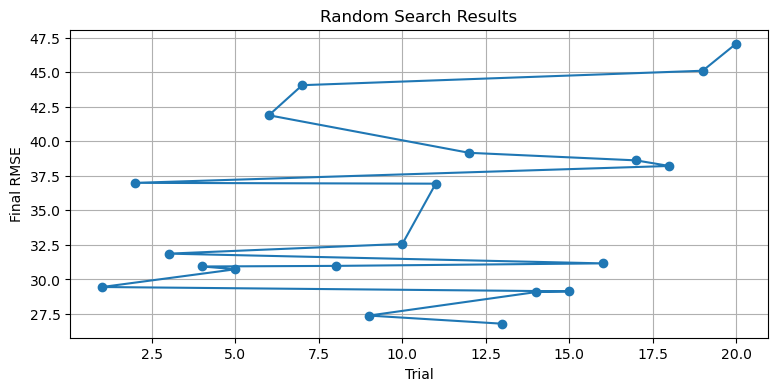

In [9]:
plt.figure(figsize=(9, 4))

plt.plot(
    random_search_df["trial"],
    random_search_df["final_rmse"],
    marker="o"
)

plt.title("Random Search Results")
plt.xlabel("Trial")
plt.ylabel("Final RMSE")
plt.grid(True)

plt.show()

## Interpretation of Trial Performance

The results reveal considerable variation in final RMSE across trials, confirming that Genetic Algorithm performance is highly sensitive to hyperparameter selection.

Some configurations converged to relatively good solutions, while others produced substantially worse image approximations. This variability demonstrates the usefulness of automated hyperparameter exploration methods such as Random Search.

Although Random Search does not use any learning mechanism to guide the search process, it is still capable of discovering competitive configurations by exploring diverse regions of the search space.

## Fitness Evolution of the Best Trial

The following plot illustrates the convergence behavior of the best configuration discovered during Random Search.

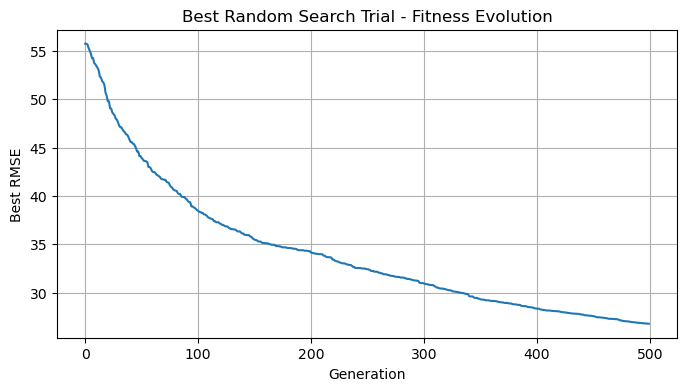

In [10]:
plt.figure(figsize=(8, 4))

plt.plot(best_random_result["history"])

plt.title("Best Random Search Trial - Fitness Evolution")
plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.grid(True)

plt.show()

## Convergence Analysis

The fitness curve shows a consistent reduction in RMSE throughout evolution.

The largest improvements occur during the early generations, where the population rapidly discovers better structural approximations of the target image. As evolution progresses, improvements become more gradual, indicating a transition from exploration to refinement.

This behavior is characteristic of Genetic Algorithms and suggests that the selected configuration achieved stable convergence without premature stagnation.

## Visual Comparison

The following figure compares the original image with the best approximation generated by Random Search.

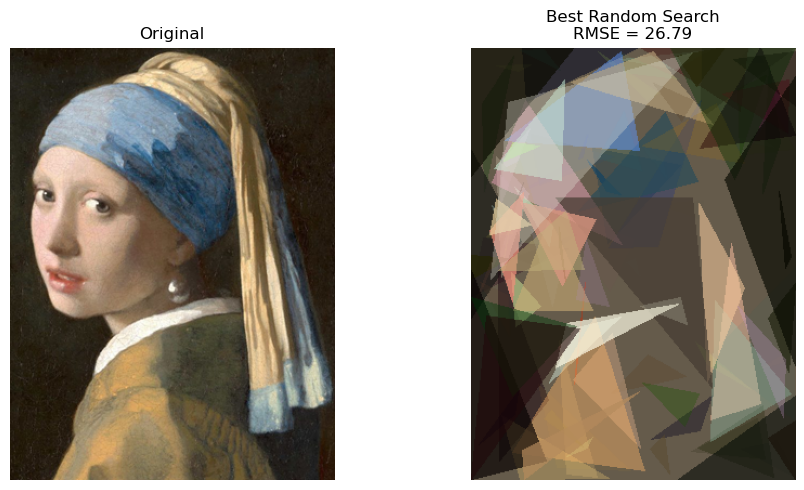

In [11]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

ax1.imshow(target)
ax1.set_title("Original")
ax1.axis("off")

ax2.imshow(best_random_result["final_image"])
ax2.set_title(
    f"Best Random Search\nRMSE = {best_random_result['final_rmse']:.2f}"
)
ax2.axis("off")

plt.tight_layout()
plt.show()

## Visual Interpretation

Although the generated image remains highly abstract, the Genetic Algorithm successfully captures several important global characteristics of the target image, including:
- overall silhouette;
- dominant color regions;
- head orientation;
- major light and shadow structures.

The approximation still lacks fine details and texture precision, which is expected given the relatively small number of triangles and limited number of generations. However, the result demonstrates that Random Search can identify configurations capable of producing meaningful image reconstructions.

## Top Random Search Configurations

The following figure presents the best image approximations obtained during the Random Search process.

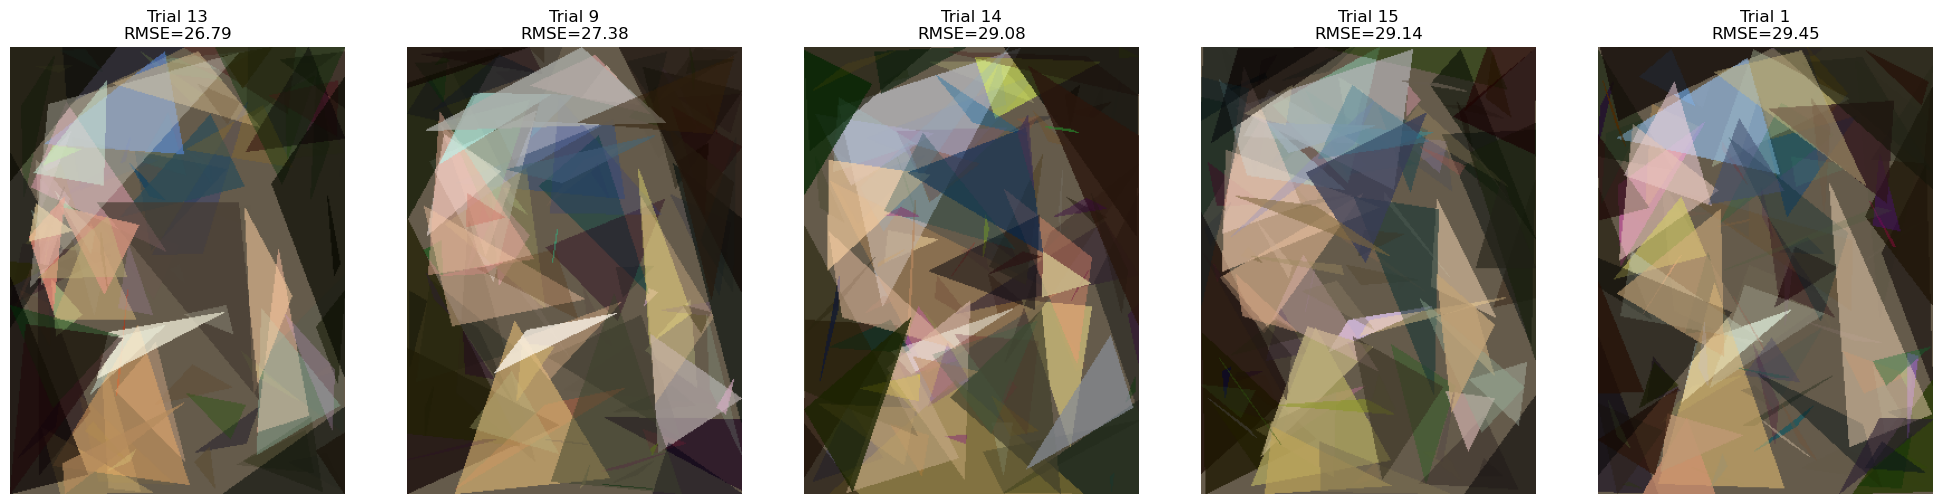

In [12]:
top_5_results = sorted(
    random_search_results,
    key=lambda x: x["final_rmse"]
)[:5]

fig, axes = plt.subplots(
    1,
    len(top_5_results),
    figsize=(4 * len(top_5_results), 5)
)

if len(top_5_results) == 1:
    axes = [axes]

for ax, result in zip(axes, top_5_results):
    ax.imshow(result["final_image"])
    ax.set_title(
        f"Trial {result['trial']}\nRMSE={result['final_rmse']:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## Comparative Analysis of Top Configurations

The top-performing configurations produce visually similar structures, particularly in:
- the head shape;
- the dark background;
- the light regions corresponding to the face and clothing.

This consistency suggests that several different hyperparameter combinations are capable of achieving competitive performance, although some configurations clearly converge faster and produce lower RMSE values.

The experiment also highlights that visually plausible solutions can emerge from very different combinations of mutation rates, crossover strategies, and population structures.

In [14]:
best_config = {
    "pop_size": best_random_result["pop_size"],
    "mutation_rate": best_random_result["mutation_rate"],
    "elite_size": best_random_result["elite_size"],
    "selection_type": best_random_result["selection_type"],
    "tournament_size": best_random_result["tournament_size"],
    "crossover_type": best_random_result["crossover_type"],
    "crossover_rate": best_random_result["crossover_rate"],
    "use_mutation_decay": best_random_result["use_mutation_decay"],
    "min_mutation_rate": best_random_result["min_mutation_rate"]
}

best_config

{'pop_size': 40,
 'mutation_rate': 0.06621852964879182,
 'elite_size': 3,
 'selection_type': 'tournament',
 'tournament_size': 8,
 'crossover_type': 'one_point',
 'crossover_rate': 0.6854730789163572,
 'use_mutation_decay': True,
 'min_mutation_rate': 0.01}

In [ ]:
LONG_RUN_GENERATIONS = 6000

best_random_long_run = evolve_configurable(
    target_img=target,
    pop_size=best_config["pop_size"],
    generations=LONG_RUN_GENERATIONS,
    mutation_rate=best_config["mutation_rate"],
    elite_size=best_config["elite_size"],
    selection_type=best_config["selection_type"],
    tournament_size=best_config["tournament_size"],
    crossover_type=best_config["crossover_type"],
    crossover_rate=best_config["crossover_rate"],
    use_mutation_decay=best_config["use_mutation_decay"],
    min_mutation_rate=best_config["min_mutation_rate"],
    snapshot_generations=[
        0,
        500,
        1000,
        2000,
        4000,
        LONG_RUN_GENERATIONS - 1
    ],
    print_every=250
)

Generation 00000 | Best RMSE: 56.1261 | Mutation: 0.0662


In [ ]:
best_random_long_image = render_individual(
    best_random_long_run["best_individual"],
    best_random_long_run["background_color"]
)

best_random_long_rmse = calculate_fitness(
    best_random_long_image,
    target
)

print(f"Final RMSE after {LONG_RUN_GENERATIONS} generations: {best_random_long_rmse:.4f}")

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(best_random_long_run["history"])

plt.title("Extended Evolution Using Best Random Search Configuration")
plt.xlabel("Generation")
plt.ylabel("Best RMSE")
plt.grid(True)

plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

ax1.imshow(target)
ax1.set_title("Original")
ax1.axis("off")

ax2.imshow(best_random_long_image)
ax2.set_title(
    f"Extended Random Search Configuration\nRMSE = {best_random_long_rmse:.2f}"
)
ax2.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
snapshots = best_random_long_run["snapshots"]

num_snapshots = len(snapshots)

fig, axes = plt.subplots(
    1,
    num_snapshots,
    figsize=(4 * num_snapshots, 5)
)

if num_snapshots == 1:
    axes = [axes]

for ax, (gen, data) in zip(axes, snapshots.items()):
    ax.imshow(data["image"])
    ax.set_title(
        f"Gen {gen}\nRMSE={data['rmse']:.2f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()